# ResNet50 Tomato Classification — Masked vs Original Background Comparison

Tests whether the ResNet50 model from `resnet50.ipynb` relies on image **background**
rather than the plant itself, using the COCO polygon segmentation annotations in
`tomato final dataset/`. This notebook is fully additive: it does not modify
`resnet50.ipynb`, `dataset_utils.py`, `dataset/`, `export/`, or `checkpoints/`.

Same architecture, hyperparameters, optimizer, LR, epochs, batch size, augmentation,
and random seed as `resnet50.ipynb`, so the only difference between the two training
runs is masked vs. unmasked background.

Four combinations are evaluated at the end:

| Train data | Eval data | What it tells us |
|---|---|---|
| original | original | baseline (already established) |
| original | masked | does the original model need background to work? |
| masked | original | does a background-free model transfer to real photos? |
| masked | masked | baseline for the masked model |


In [1]:
import os
import copy
import time
import random
import csv

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Identical seed/determinism settings to resnet50.ipynb
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ---- Config (identical hyperparameters to resnet50.ipynb) ----
PROJECT_ROOT = r"d:\Reasearch\Resnet50test"
DATA_DIR_MASKED = os.path.join(PROJECT_ROOT, "tomato final dataset_masked")
DATA_DIR_ORIGINAL = os.path.join(PROJECT_ROOT, "tomato final dataset")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints_masked")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

ORIGINAL_CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "export", "resnet50_tomato_final.pth")

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 4
FREEZE_BACKBONE = False

## 1. Data loading

`tomato final dataset/` and its masked mirror are laid out split-first/class-inside
(`root/<split>/<class>/*.jpg`) -- the opposite nesting from `dataset_utils.SplitFolderDataset`,
which reads the older `dataset/` folder (`root/<class>/<split>/*.jpg`) used by `resnet50.ipynb`.
Since `dataset_utils.py` must not change, a small sibling loader
(`masked_comparison_utils.SplitFirstFolderDataset`) reads this layout instead -- same
interface and conventions, just the correct nesting order.

Four dataset objects are built: masked train/valid/test (for training + the masked-side of
the comparison), and original test (for the cross-evaluation).

In [3]:
# Identical transforms to resnet50.ipynb
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

from masked_comparison_utils import SplitFirstFolderDataset

train_ds = SplitFirstFolderDataset(DATA_DIR_MASKED, "train", train_transform)
class_names = train_ds.classes
num_classes = len(class_names)
val_ds = SplitFirstFolderDataset(DATA_DIR_MASKED, "valid", eval_transform, classes=class_names)
test_ds = SplitFirstFolderDataset(DATA_DIR_MASKED, "test", eval_transform, classes=class_names)

# Original (unmasked) test set, same class order enforced so label indices match exactly
test_ds_original = SplitFirstFolderDataset(DATA_DIR_ORIGINAL, "test", eval_transform, classes=class_names)

print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_original = DataLoader(test_ds_original, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train (masked): {len(train_ds)} | Val (masked): {len(val_ds)} | "
      f"Test (masked): {len(test_ds)} | Test (original): {len(test_ds_original)}")

Classes: ['developing', 'flowering', 'fruiting', 'seeding']
Train (masked): 684 | Val (masked): 135 | Test (masked): 160 | Test (original): 160


## 2. Model — ResNet50 with a new classifier head

Identical to `resnet50.ipynb`: ImageNet-pretrained ResNet50, final fc replaced with
`nn.Linear(2048, num_classes)`, full network fine-tuned.

In [4]:
def build_model():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if FREEZE_BACKBONE:
        for p in m.parameters():
            p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

model = build_model()

criterion = nn.CrossEntropyLoss()
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

print(f"Trainable params: {sum(p.numel() for p in params_to_update):,}")

Trainable params: 23,516,228


## 3. Training loop

Trains for `NUM_EPOCHS` on the **masked** train/valid sets, saves the checkpoint with the
best validation accuracy to `checkpoints_masked/resnet50_masked_best.pt`.

In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, running_correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()
            total += inputs.size(0)

    return running_loss / total, running_correct / total

In [6]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
best_ckpt_path = os.path.join(CHECKPOINT_DIR, "resnet50_masked_best.pt")

start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            "model_state_dict": best_model_wts,
            "class_names": class_names,
            "epoch": epoch,
            "val_acc": val_acc,
        }, best_ckpt_path)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
print(f"Best val accuracy: {best_val_acc:.4f} (saved to {best_ckpt_path})")

model.load_state_dict(best_model_wts)
model.eval()

Epoch 01/20 | train_loss 0.9120 train_acc 0.7032 | val_loss 0.5751 val_acc 0.8963
Epoch 02/20 | train_loss 0.3831 train_acc 0.8538 | val_loss 0.2523 val_acc 0.8963
Epoch 03/20 | train_loss 0.2587 train_acc 0.8904 | val_loss 0.1859 val_acc 0.9111
Epoch 04/20 | train_loss 0.2553 train_acc 0.9064 | val_loss 0.2545 val_acc 0.8963
Epoch 05/20 | train_loss 0.1921 train_acc 0.9225 | val_loss 0.1275 val_acc 0.9407
Epoch 06/20 | train_loss 0.1686 train_acc 0.9401 | val_loss 0.1512 val_acc 0.9333
Epoch 07/20 | train_loss 0.1390 train_acc 0.9444 | val_loss 0.2070 val_acc 0.9333
Epoch 08/20 | train_loss 0.1220 train_acc 0.9503 | val_loss 0.1655 val_acc 0.9259
Epoch 09/20 | train_loss 0.0979 train_acc 0.9620 | val_loss 0.1185 val_acc 0.9407
Epoch 10/20 | train_loss 0.0761 train_acc 0.9737 | val_loss 0.1367 val_acc 0.9556
Epoch 11/20 | train_loss 0.0607 train_acc 0.9781 | val_loss 0.1410 val_acc 0.9481
Epoch 12/20 | train_loss 0.0654 train_acc 0.9795 | val_loss 0.1835 val_acc 0.9333
Epoch 13/20 | tr

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 4. Training curves

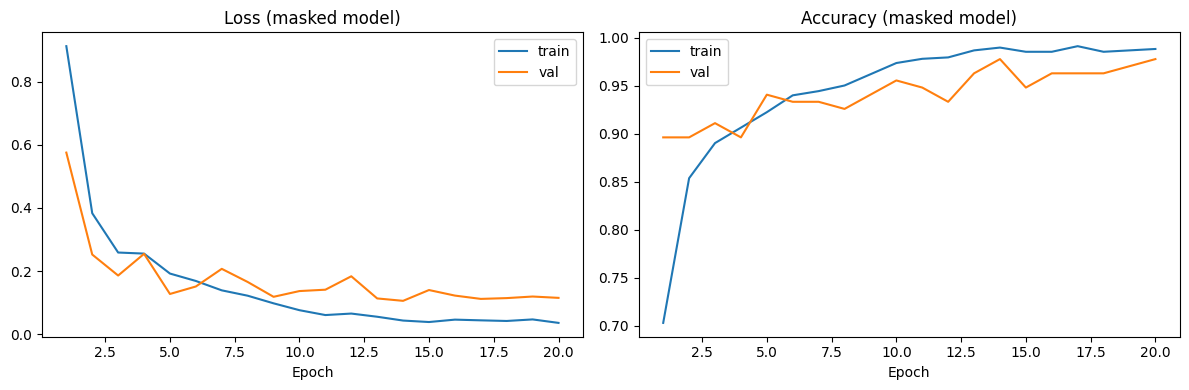

In [7]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss (masked model)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].set_title("Accuracy (masked model)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Four-way comparison: does the model rely on background?

Helper to evaluate any model checkpoint against any loader, returning accuracy and the
full classification report so all four combinations are computed with identical code.

c:\Users\KOSALA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KOSALA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KOSALA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

=== train=masked eval=masked === test accuracy: 0.9187
              precision    recall  f1-score   support

  developing       0.98      0.98      0.98        41
   flowering       0.88      0.95      0.91        60
    fruiting       0.86      0.57      0.69        21
     seeding       0.95      1.00      0.97        38

    accuracy                           0.92       160
   macro avg       0.91      0.87      0.89       160
weighted avg       0.92      0.92      0.91       160



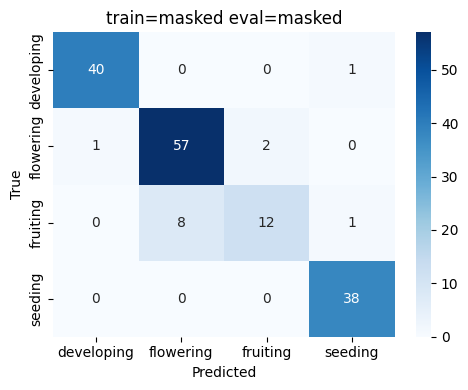

=== train=masked eval=original === test accuracy: 0.3563
              precision    recall  f1-score   support

  developing       0.36      1.00      0.53        41
   flowering       0.00      0.00      0.00        60
    fruiting       0.36      0.76      0.48        21
     seeding       0.00      0.00      0.00        38

    accuracy                           0.36       160
   macro avg       0.18      0.44      0.25       160
weighted avg       0.14      0.36      0.20       160



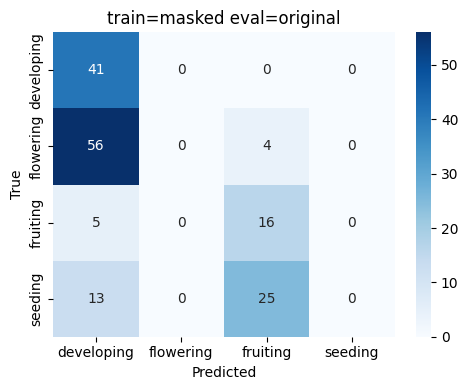

=== train=original eval=masked === test accuracy: 0.7688
              precision    recall  f1-score   support

  developing       0.86      0.93      0.89        41
   flowering       0.67      0.82      0.74        60
    fruiting       0.00      0.00      0.00        21
     seeding       0.84      0.95      0.89        38

    accuracy                           0.77       160
   macro avg       0.59      0.67      0.63       160
weighted avg       0.67      0.77      0.72       160



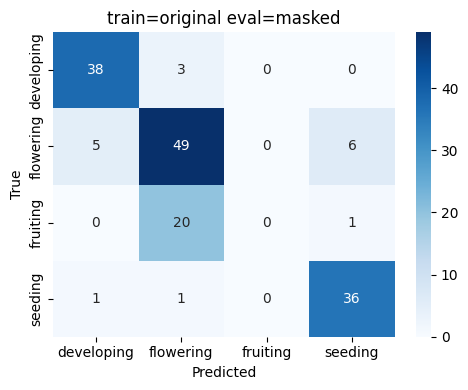

=== train=original eval=original === test accuracy: 0.9688
              precision    recall  f1-score   support

  developing       0.95      1.00      0.98        41
   flowering       0.97      0.95      0.96        60
    fruiting       0.95      0.90      0.93        21
     seeding       1.00      1.00      1.00        38

    accuracy                           0.97       160
   macro avg       0.97      0.96      0.97       160
weighted avg       0.97      0.97      0.97       160



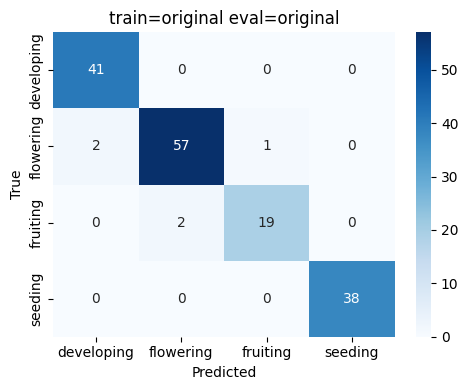

In [8]:
def evaluate(eval_model, loader):
    eval_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = eval_model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy() if hasattr(labels, "numpy") else labels)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_text = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, report, report_text, cm


def load_original_model():
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    state_dict = torch.load(ORIGINAL_CHECKPOINT_PATH, map_location=device, weights_only=True)
    m.load_state_dict(state_dict)
    return m.to(device)


masked_model = model  # already trained + best weights loaded above
original_model = load_original_model()

results = {}
results[("masked", "masked")] = evaluate(masked_model, test_loader)
results[("masked", "original")] = evaluate(masked_model, test_loader_original)
results[("original", "masked")] = evaluate(original_model, test_loader)
results[("original", "original")] = evaluate(original_model, test_loader_original)

for (train_data, eval_data), (acc, report, report_text, cm) in results.items():
    print(f"=== train={train_data} eval={eval_data} === test accuracy: {acc:.4f}")
    print(report_text)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"train={train_data} eval={eval_data}")
    plt.tight_layout()
    plt.show()

In [9]:
# Final comparison table
table_rows = []
for train_data in ["original", "masked"]:
    for eval_data in ["original", "masked"]:
        acc, report, report_text, cm = results[(train_data, eval_data)]
        table_rows.append({"train_data": train_data, "eval_data": eval_data, "test_accuracy": round(float(acc), 4)})

print(f"{'Train data':<12}{'Eval data':<12}{'Test accuracy':<15}")
for r in table_rows:
    print(f"{r['train_data']:<12}{r['eval_data']:<12}{r['test_accuracy']:<15}")

csv_path = os.path.join(PROJECT_ROOT, "masked_vs_original_comparison.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["train_data", "eval_data", "test_accuracy"])
    writer.writeheader()
    writer.writerows(table_rows)
print(f"\nSaved to {csv_path}")

Train data  Eval data   Test accuracy  
original    original    0.9688         
original    masked      0.7688         
masked      original    0.3563         
masked      masked      0.9187         

Saved to d:\Reasearch\Resnet50test\masked_vs_original_comparison.csv


In [10]:
# Interpretation, computed from the actual numbers above
oo = results[("original", "original")][0]
om = results[("original", "masked")][0]
mo = results[("masked", "original")][0]
mm = results[("masked", "masked")][0]

print("Interpretation")
print("=" * 60)
print(f"original model, original eval: {oo:.4f}")
print(f"original model, masked eval:   {om:.4f}  (drop: {oo - om:+.4f})")
print(f"masked model,   masked eval:   {mm:.4f}")
print(f"masked model,   original eval: {mo:.4f}  (drop: {mm - mo:+.4f})")
print()
if oo - om > 0.05:
    print("The original model\'s accuracy drops notably when the background is removed at "
          "eval time -> it is relying on background context, not just the plant, to classify "
          "growth stage.")
else:
    print("The original model\'s accuracy holds up when the background is removed at eval time "
          "-> little evidence it depends on background; performance looks driven by the plant itself.")
if mm - mo > 0.05:
    print("The masked-trained model does notably worse on real (unmasked) photos than on masked "
          "ones -> it learned features tied to the artificial black background / mask edges, "
          "which will not transfer to real deployment images.")
else:
    print("The masked-trained model transfers reasonably well to real (unmasked) photos -> its "
          "learned features are not overly tied to the artificial masking.")

Interpretation
original model, original eval: 0.9688
original model, masked eval:   0.7688  (drop: +0.2000)
masked model,   masked eval:   0.9187
masked model,   original eval: 0.3563  (drop: +0.5625)

The original model's accuracy drops notably when the background is removed at eval time -> it is relying on background context, not just the plant, to classify growth stage.
The masked-trained model does notably worse on real (unmasked) photos than on masked ones -> it learned features tied to the artificial black background / mask edges, which will not transfer to real deployment images.


## 6. Export (only if useful for the fusion project)

Exports the masked-trained model the same way as the original (`export/`), into a separate
`export_masked/` folder, tagged clearly as the background-ablation comparison model -- not a
replacement for the production model in `export/`.

In [ ]:
import json
import datetime

EXPORT_DIR = os.path.join(PROJECT_ROOT, "export_masked")
os.makedirs(EXPORT_DIR, exist_ok=True)

ckpt = torch.load(best_ckpt_path, map_location="cpu", weights_only=False)
torch.save(ckpt["model_state_dict"], os.path.join(EXPORT_DIR, "resnet50_tomato_masked.pth"))

metadata = {
    "architecture": "resnet50",
    "modifications": "Same as export/resnet50_tomato_final.pth (fc replaced with nn.Linear(2048,4), "
                      "full fine-tune), but TRAINED ON BACKGROUND-MASKED IMAGES (COCO polygon "
                      "segmentation from tomato final dataset/, background pixels set to black) as "
                      "part of a background-reliance ablation study. Not a production replacement for "
                      "export/resnet50_tomato_final.pth.",
    "input_size": [224, 224, 3],
    "num_classes": num_classes,
    "class_names": class_names,
    "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    "training": {
        "epochs_run": NUM_EPOCHS,
        "best_epoch": int(ckpt["epoch"]),
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "train_data": "tomato final dataset_masked/train",
    },
    "val_accuracy_at_best_epoch": float(ckpt["val_acc"]),
    "background_ablation_comparison": {
        "train_original_eval_original": float(oo),
        "train_original_eval_masked": float(om),
        "train_masked_eval_original": float(mo),
        "train_masked_eval_masked": float(mm),
    },
    "training_date": datetime.date.today().isoformat(),
    "framework": {"torch": torch.__version__},
    "source_checkpoint": "checkpoints_masked/resnet50_masked_best.pt",
}
with open(os.path.join(EXPORT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Exported to", EXPORT_DIR)

In [ ]:
feature_extractor_code = '''"""Standalone loader for the MASKED-TRAINED tomato growth-stage ResNet50 checkpoint,
used as a background-reliance comparison point alongside export/resnet_feature_extractor.py.
Copy-paste this file into another project with no other dependency on training code.
"""
import torch
import torch.nn as nn
from torchvision import transforms, models

NUM_CLASSES = {num_classes}
CLASS_NAMES = {class_names!r}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

PREPROCESS = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def load_resnet_feature_extractor(checkpoint_path, device=None):
    """Loads the masked-trained checkpoint and returns it as a 2048-dim feature extractor."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device(device) if not isinstance(device, torch.device) else device

    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)

    model.fc = nn.Identity()
    model = model.to(device)
    model.eval()
    return model
'''.format(num_classes=num_classes, class_names=class_names)

with open(os.path.join(EXPORT_DIR, "resnet_feature_extractor.py"), "w", encoding="utf-8") as f:
    f.write(feature_extractor_code)

print("Wrote", os.path.join(EXPORT_DIR, "resnet_feature_extractor.py"))